# Pneumonia Detection with DenseNet121 on the RSNA Dataset. Full Pipeline in One Notebook

**Project:** Multimodal Explainable AI for Chest Radiology, Master 2 ISI
**Scope:** data preprocessing, model training and full evaluation in a single reproducible file, identical in every step to the ResNet50 RSNA notebook of the project except for the backbone. Running the two notebooks on the same frozen protocol gives a controlled two backbone comparison on RSNA, extending the four backbone study already performed on Kermany.

**Backbone: DenseNet121 pretrained on ImageNet.** DenseNet121 is the reference backbone of chest radiography since CheXNet, Rajpurkar et al. 2017, appears in the PLOS ONE 2024 study and is the classifier of the Nature Machine Intelligence 2022 saliency benchmark reference pipeline, Grad-CAM plus DenseNet121, both in the SOTA table. It also won our own four backbone comparison on Kermany with the best AUC at the smallest parameter count, seven million against twenty three for ResNet50.

**Dataset: RSNA Pneumonia Detection Challenge,** in the SOTA table via the Ensemble-CAM 2024 paper. Adult patients, patient identifiers enabling a leak free split, expert bounding boxes for the CAM evaluation.

**Kaggle setup.** Attach the competition `rsna-pneumonia-detection-challenge` from the Competitions tab of Add Input, rules accepted once on the competition page, GPU T4, Internet On.

**Outputs saved in `/kaggle/working`:**
1. `densenet121_rsna_best.pth` best model weights
2. `rsna_train.csv`, `rsna_val.csv`, `rsna_test.csv` frozen patient level splits
3. `rsna_bboxes_eval.csv` expert boxes of the test split
4. `densenet121_rsna_test_predictions.csv` and `densenet121_rsna_metrics.json`
5. Training curves, ROC curve and confusion matrix figures


## Part 1. Setup and reproducibility

The seed 42 policy of the project, applied to every random generator. Because the seed and the split logic are identical to the ResNet50 notebook, both backbones see exactly the same train, validation and test patients, which is the condition for a fair comparison.

In [1]:
import pydicom
import os
import glob
import json
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "/kaggle/working"
print("Device:", DEVICE)

Device: cpu


## Part 2. Locate the data

The dataset root is resolved by searching for the labels file, so the notebook survives mount name changes between Kaggle sessions.

In [2]:
labels_path = glob.glob("/kaggle/input/**/stage_2_train_labels.csv", recursive=True)[0]
DATA_ROOT = os.path.dirname(labels_path)
IMG_DIR = os.path.join(DATA_ROOT, "stage_2_train_images")
print("Data root:", DATA_ROOT)

labels = pd.read_csv(labels_path)
classes = pd.read_csv(os.path.join(DATA_ROOT, "stage_2_detailed_class_info.csv"))
print("Label rows:", len(labels))
print(classes["class"].value_counts())

Data root: /kaggle/input/competitions/rsna-pneumonia-detection-challenge
Label rows: 30227
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64


## Part 3. Preprocessing step one, clean binary table

Identical rule to the ResNet50 notebook, justified by the binary task definitions of MDPI 2025 and PLOS ONE 2024. Normal versus Lung Opacity, exclusion of the ambiguous No Lung Opacity Not Normal group whose other pathologies would pollute the negative class, deduplication to one row per image.

In [3]:
table = labels.merge(classes, on="patientId", how="left").drop_duplicates("patientId")
table = table[table["class"].isin(["Normal", "Lung Opacity"])].reset_index(drop=True)

table["label"] = np.where(table["class"] == "Lung Opacity", "PNEUMONIA", "NORMAL")
table["target"] = (table["label"] == "PNEUMONIA").astype(int)
table["filepath"] = table["patientId"].apply(lambda p: os.path.join(IMG_DIR, p + ".dcm"))
table = table[table["filepath"].apply(os.path.exists)].reset_index(drop=True)

print(table["label"].value_counts())
print("Total usable images:", len(table))

label
NORMAL       8851
PNEUMONIA    6012
Name: count, dtype: int64
Total usable images: 14863


## Part 4. Preprocessing step two, patient level split

Same seed, same proportions 70 10 20, same stratification as the ResNet50 notebook, therefore the exact same patients land in each subset. The patient level split corrects the limitation acknowledged by PLOS ONE 2024, and disjointness is verified by assertions.

In [4]:
from sklearn.model_selection import train_test_split

patients = table["patientId"].to_numpy()
strata = table["target"].to_numpy()

train_p, temp_p, strat_train, strat_temp = train_test_split(
    patients, strata, test_size=0.30, stratify=strata, random_state=SEED)
val_p, test_p = train_test_split(
    temp_p, test_size=2/3, stratify=strat_temp, random_state=SEED)

train_df = table[table["patientId"].isin(train_p)].reset_index(drop=True)
val_df = table[table["patientId"].isin(val_p)].reset_index(drop=True)
test_df = table[table["patientId"].isin(test_p)].reset_index(drop=True)

assert set(train_df.patientId).isdisjoint(test_df.patientId)
assert set(train_df.patientId).isdisjoint(val_df.patientId)
assert set(val_df.patientId).isdisjoint(test_df.patientId)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, len(d), " pneumonia ratio", round(d["target"].mean(), 3))

bboxes = labels.merge(pd.DataFrame({"patientId": test_p}), on="patientId")
bboxes = bboxes.dropna(subset=["x"]).reset_index(drop=True)
bboxes.to_csv(os.path.join(OUTPUT_DIR, "rsna_bboxes_eval.csv"), index=False)
print("Expert boxes kept for the test split:", len(bboxes))

cols = ["patientId", "filepath", "class", "label", "target"]
train_df[cols].to_csv(os.path.join(OUTPUT_DIR, "rsna_train.csv"), index=False)
val_df[cols].to_csv(os.path.join(OUTPUT_DIR, "rsna_val.csv"), index=False)
test_df[cols].to_csv(os.path.join(OUTPUT_DIR, "rsna_test.csv"), index=False)
print("Splits frozen on disk")

train 10404  pneumonia ratio 0.404
val 1486  pneumonia ratio 0.404
test 2973  pneumonia ratio 0.405
Expert boxes kept for the test split: 1917
Splits frozen on disk


## Part 5. Preprocessing step three, DICOM reading, transformations and loaders

DICOM decoding, resize to 224, ImageNet normalization required by the pretrained weights, and the augmentation with the exact parameters of the MDPI Information 2025 paper, rotation fifteen degrees, horizontal flip, zoom, on the training set only. The grayscale image is replicated to three channels for the RGB backbone.

In [5]:
def read_dicom(filepath):
    dcm = pydicom.dcmread(filepath)
    arr = dcm.pixel_array.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255.0
    return arr.astype(np.uint8)

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(15),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class RsnaDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = read_dicom(row["filepath"])
        img = Image.fromarray(arr).convert("RGB")
        return self.transform(img), torch.tensor(row["target"], dtype=torch.long)

BATCH_SIZE = 32
train_loader = DataLoader(RsnaDataset(train_df, train_transform), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(RsnaDataset(val_df, eval_transform), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(RsnaDataset(test_df, eval_transform), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)
print("Batches per training epoch:", len(train_loader))

Batches per training epoch: 326


## Part 6. Model, DenseNet121 with transfer learning

The only line that differs from the ResNet50 notebook. DenseNet121 is loaded with ImageNet weights and its classifier layer is replaced by a two class head. The dense connectivity of the architecture reuses features across blocks, which explains its strong accuracy at only seven million parameters and made it the CheXNet choice. Loss, weighting, optimizer and scheduler stay strictly identical, weighted cross entropy from Ensemble-CAM, Adam 1e-4 from Nature Machine Intelligence 2022, ReduceLROnPlateau from PLOS ONE 2024.

In [6]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model = model.to(DEVICE)

counts = train_df["target"].value_counts().sort_index().values
class_weights = torch.tensor(len(train_df) / (2.0 * counts), dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights.cpu().numpy().round(3))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                       factor=0.1, patience=2)
print("Trainable parameters in millions:",
      round(sum(p.numel() for p in model.parameters()) / 1e6, 1))

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 94.2MB/s]


Class weights: [0.84  1.236]
Trainable parameters in millions: 7.0


## Part 7. Training with early stopping

Same budget policy as the ResNet50 notebook, a cap of ten epochs with patience three on the validation AUC, the model selection practice of PLOS ONE 2024 and Ensemble-CAM, the caps of fifty epochs reported in the literature being upper bounds under early stopping on smaller datasets.

In [7]:
from sklearn.metrics import roc_auc_score

def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    with torch.set_grad_enabled(train_mode):
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(targets)
            all_labels.extend(targets.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy())
    return total_loss / len(loader.dataset), np.array(all_labels), np.array(all_probs)

EPOCHS = 10
PATIENCE = 3
CKPT = os.path.join(OUTPUT_DIR, "densenet121_rsna_best.pth")
best_auc, without_improvement = 0.0, 0
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, _, _ = run_epoch(train_loader, True)
    val_loss, val_labels, val_probs = run_epoch(val_loader, False)
    val_auc = roc_auc_score(val_labels, val_probs)
    scheduler.step(val_auc)
    history.append({"epoch": epoch, "train_loss": train_loss,
                    "val_loss": val_loss, "val_auc": val_auc})
    print(f"epoch {epoch}  train_loss {train_loss:.4f}  val_loss {val_loss:.4f}"
          f"  val_auc {val_auc:.4f}  minutes {round((time.time() - start) / 60, 1)}")
    if val_auc > best_auc:
        best_auc, without_improvement = val_auc, 0
        torch.save(model.state_dict(), CKPT)
        print("new best model saved")
    else:
        without_improvement += 1
        if without_improvement >= PATIENCE:
            print("early stopping")
            break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 1  train_loss 0.2301  val_loss 0.1576  val_auc 0.9849  minutes 53.3
new best model saved


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 2  train_loss 0.1756  val_loss 0.1418  val_auc 0.9865  minutes 52.1
new best model saved


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

epoch 4  train_loss 0.1463  val_loss 0.1393  val_auc 0.9869  minutes 52.1


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 5  train_loss 0.1351  val_loss 0.1307  val_auc 0.9882  minutes 52.2


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 6  train_loss 0.1315  val_loss 0.1559  val_auc 0.9862  minutes 52.3
early stopping


## Part 8. Evaluation on the held out test set

The best checkpoint is reloaded and evaluated once on the untouched test split with the metric set of the project, Accuracy, Precision, Recall, F1 and AUC of the PLOS ONE 2024 protocol. The direct comparison point is the ResNet50 run of the project on the exact same split, accuracy 0.9448 and AUC 0.9868, so any difference observed here is attributable to the backbone alone.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


accuracy: 0.9418
precision: 0.9518
recall: 0.9019
f1: 0.9262
auc: 0.9853


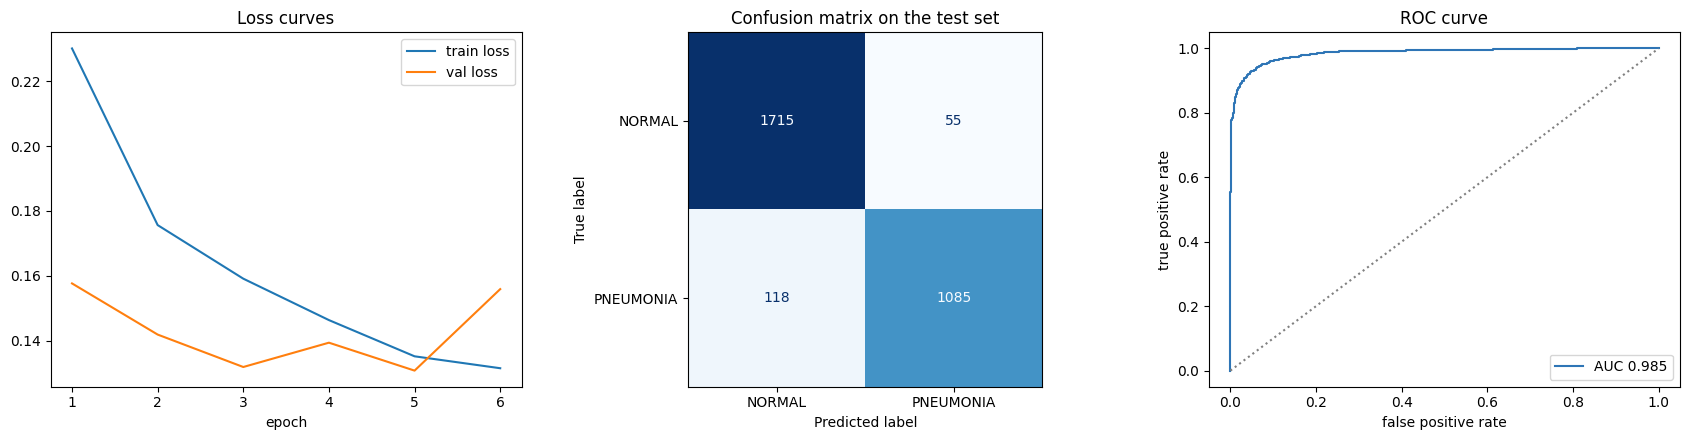

In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)

model.load_state_dict(torch.load(CKPT))
_, test_labels, test_probs = run_epoch(test_loader, False)
test_preds = (test_probs >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(test_labels, test_preds),
    "precision": precision_score(test_labels, test_preds),
    "recall": recall_score(test_labels, test_preds),
    "f1": f1_score(test_labels, test_preds),
    "auc": roc_auc_score(test_labels, test_probs)
}
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

with open(os.path.join(OUTPUT_DIR, "densenet121_rsna_metrics.json"), "w") as f:
    json.dump({k: round(v, 4) for k, v in metrics.items()}, f, indent=2)

hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].plot(hist["epoch"], hist["train_loss"], label="train loss")
axes[0].plot(hist["epoch"], hist["val_loss"], label="val loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].set_title("Loss curves")

cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"]).plot(
    cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion matrix on the test set")

fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[2].plot(fpr, tpr, color="#2E75B6", label=f"AUC {metrics['auc']:.3f}")
axes[2].plot([0, 1], [0, 1], linestyle=":", color="gray")
axes[2].set_xlabel("false positive rate")
axes[2].set_ylabel("true positive rate")
axes[2].legend()
axes[2].set_title("ROC curve")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "densenet121_rsna_evaluation.png"), dpi=200,
            bbox_inches="tight")
plt.show()

## Part 9. Save the per image predictions

The predictions file keeps the backbone name in its file name so the ResNet50 and DenseNet121 outputs can live in the same results dataset without collision. These predictions also allow the CAM notebook to be re run on the DenseNet121 model, whose target layer for CAM is the last dense block, features minus one, following the Grad-CAM recommendation of the deepest convolutional layer.

In [9]:
out = test_df[["patientId", "label", "target"]].copy()
out["prob_pneumonia"] = test_probs
out["prediction"] = test_preds
out.to_csv(os.path.join(OUTPUT_DIR, "densenet121_rsna_test_predictions.csv"), index=False)

print("Final content of the working directory:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" ", f)

Final content of the working directory:
  __notebook__.ipynb
  densenet121_rsna_best.pth
  densenet121_rsna_evaluation.png
  densenet121_rsna_metrics.json
  densenet121_rsna_test_predictions.csv
  rsna_bboxes_eval.csv
  rsna_test.csv
  rsna_train.csv
  rsna_val.csv


## Part 10. Grad-CAM explanation with expert boxes

Grad-CAM following its original paper, Selvaraju et al. ICCV 2017, applied to the trained model on the deepest convolutional block, the recommended target layer. One example of each confusion category is explained, true positive, true negative, false positive and false negative, because heatmaps of errors reveal what confused the model, a use of explanations promoted by the PLOS ONE 2024 study. The expert boxes are drawn in red on the pneumonia images, giving an immediate visual check of whether the highlighted regions match the expert localization before the full quantitative CAM evaluation of the dedicated notebook.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
category
true negative     1715
true positive     1085
false negative     118
false positive      55
Name: count, dtype: int64


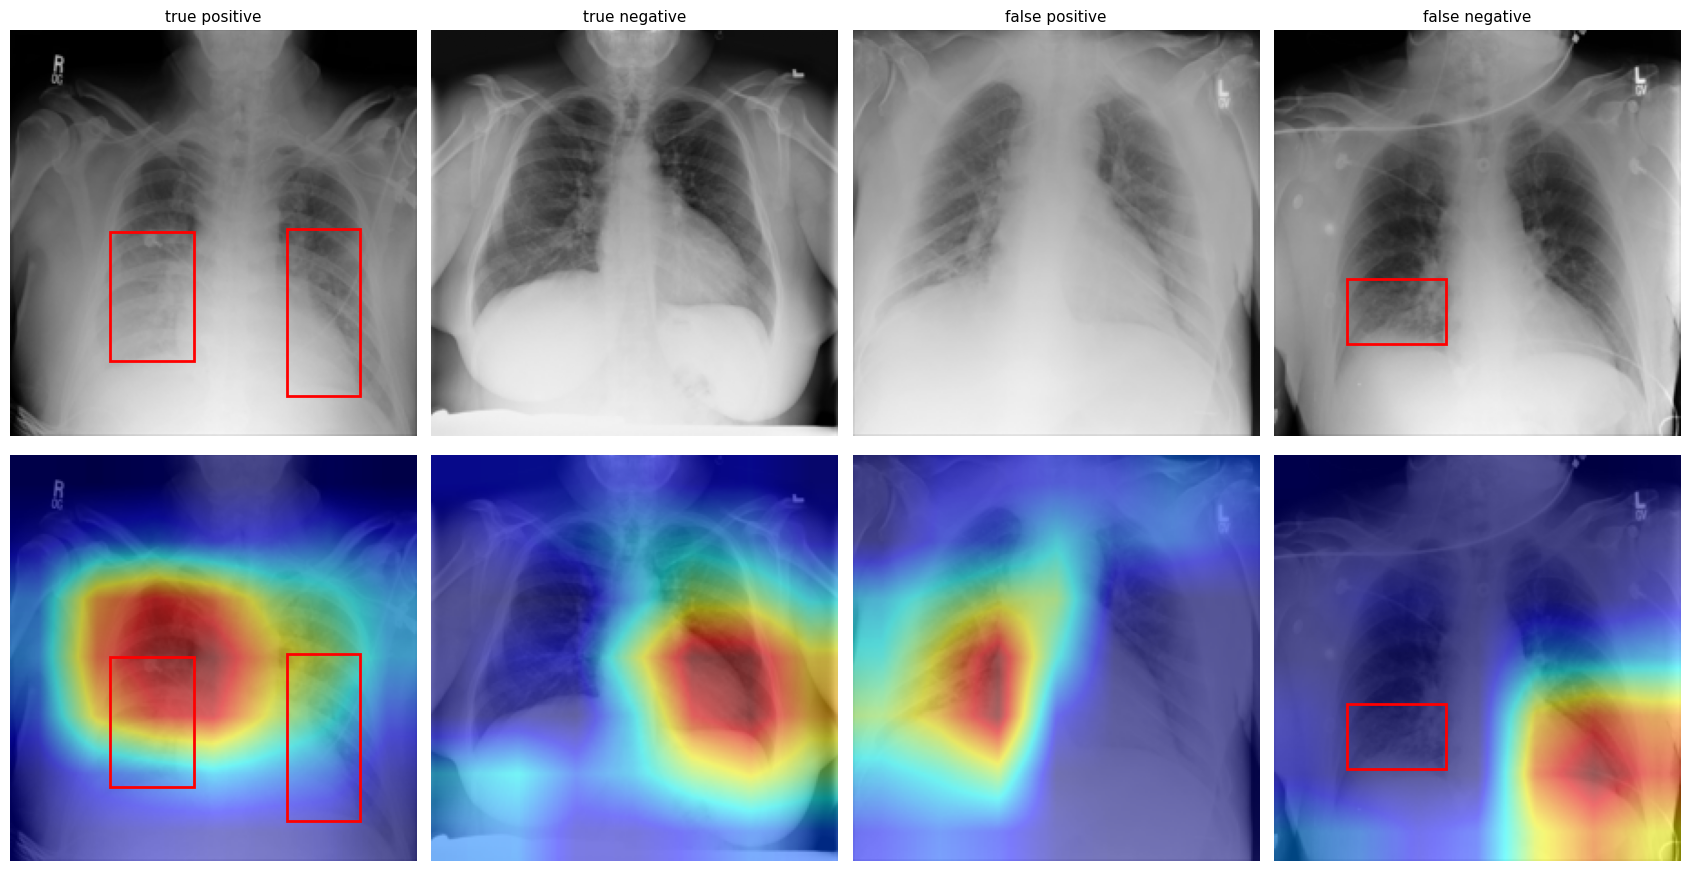

In [10]:
!pip install grad-cam --quiet
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.patches as patches

model.eval()
cam = GradCAM(model=model, target_layers=[model.features[-1]])

def load_for_cam(filepath):
    arr = read_dicom(filepath)
    img = Image.fromarray(arr).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(DEVICE)
    display = np.array(img.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255.0
    return tensor, display, arr.shape

test_eval = test_df.reset_index(drop=True).copy()
test_eval["prediction"] = test_preds

def category(row):
    if row["target"] == 1 and row["prediction"] == 1:
        return "true positive"
    if row["target"] == 0 and row["prediction"] == 0:
        return "true negative"
    if row["target"] == 0 and row["prediction"] == 1:
        return "false positive"
    return "false negative"

test_eval["category"] = test_eval.apply(category, axis=1)
print(test_eval["category"].value_counts())

fig, axes = plt.subplots(2, 4, figsize=(17, 9))
for c, cat in enumerate(["true positive", "true negative",
                         "false positive", "false negative"]):
    pool = test_eval[test_eval["category"] == cat]
    row = pool.sample(1, random_state=SEED).iloc[0]
    tensor, display, (h, w) = load_for_cam(row["filepath"])
    heatmap = cam(input_tensor=tensor,
                  targets=[ClassifierOutputTarget(int(row["prediction"]))])[0]

    axes[0, c].imshow(display)
    for _, b in labels[(labels["patientId"] == row["patientId"]) &
                       labels["x"].notna()].iterrows():
        axes[0, c].add_patch(patches.Rectangle(
            (b["x"] / w * IMG_SIZE, b["y"] / h * IMG_SIZE),
            b["width"] / w * IMG_SIZE, b["height"] / h * IMG_SIZE,
            linewidth=2, edgecolor="red", facecolor="none"))
    axes[0, c].set_title(cat, fontsize=11)
    axes[0, c].axis("off")

    axes[1, c].imshow(show_cam_on_image(display, heatmap, use_rgb=True))
    for _, b in labels[(labels["patientId"] == row["patientId"]) &
                       labels["x"].notna()].iterrows():
        axes[1, c].add_patch(patches.Rectangle(
            (b["x"] / w * IMG_SIZE, b["y"] / h * IMG_SIZE),
            b["width"] / w * IMG_SIZE, b["height"] / h * IMG_SIZE,
            linewidth=2, edgecolor="red", facecolor="none"))
    axes[1, c].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "densenet121_rsna_gradcam.png"),
            dpi=200, bbox_inches="tight")
plt.show()

## Part 11. Reading the Grad-CAM figure

Four situations to inspect. On the true positive the heatmap should overlap the red expert boxes, which is the qualitative preview of the mIoU computed in the dedicated CAM notebook. On the true negative a diffuse low intensity map is expected since no lesion drives the decision. On the false positive the heatmap shows which region the model wrongly interpreted as an opacity. On the false negative it shows whether the model looked at the right region and still missed the lesion, or looked elsewhere entirely, two different failure modes with different clinical implications.